# Not So Deep MLP!!

NOTE this one is easiest to "solve" via histogram summaries of hidden layer activations, but those are unfortunately cumbersome to get with our high-level modules and training functions. If you struggle, just see if you can find weird things in the code and move on.

In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
import os
# NOTE!
# this is for a multi-gpu setup. we basically set which GPU is visible for the program.
# if you only have one GPU (most likely the case ;) ), make sure this is set to "0"!
# or remove this line completely!
# otherwise you may accidentally make your GPU "invisible" to the program!
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from torch import nn

from idl.common import ClassifierTrainer, TensorboardLogger, count_parameters, get_datasets_and_loaders
from idl.week1.analysis import plot_learning_curves

/Users/mitaly/Documents/GitHub/Deep-Learning-with-PyTorch-Portfolio/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [4]:
batch_size = 128
train_data, test_data, train_dataloader, test_dataloader = get_datasets_and_loaders("mnist", batch_size=batch_size, num_workers=8, verbose=False)

## Model

Okay, the previous models were maybe a bit deep. I regret nothing though!

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

n_layers = 2
hidden_dim = 128
input_dim = 784
model = nn.Sequential(nn.Flatten())
for ind in range(n_layers):
    model.append(nn.Linear(input_dim if ind == 0 else hidden_dim, hidden_dim))
    model.append(nn.ReLU())
model.append(nn.Linear(hidden_dim, 10))

print(model)


def _init(layer: nn.Module):
    if isinstance(layer, nn.Linear):
        nn.init.uniform_(layer.weight, -0.1, 0.)
        nn.init.zeros_(layer.bias)


with torch.no_grad():
    model.apply(_init)

model = model.to(device)

Using cpu device
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
n_params = count_parameters(model)
print(f"Model with {n_params:,d} parameters.")

Model with 118,282 parameters.


## Training

The important change is the new `logger` object. Some NOTES:
- You might want to empty the log directory after each run (or rather, before starting a new one with the same directory), or take care to choose a new directory for each run. For example, `fail1_run0`, `fail1_run1`, etc.
  - Advanced exercise: Automate this process of creating new numbered "versions" :)
- In case things go wrong in training very early, you can reduce `step_frequency` (extrem case: `step_frequency=1` and train for just a single epoch. This can give you a better view of what happens when.

In [7]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

logger = TensorboardLogger("logs/fail3", step_frequency=100)

trainer = ClassifierTrainer(model=model, optimizer=optimizer, logger=logger,
                            training_loader=train_dataloader, validation_loader=test_dataloader,
                            n_epochs=40, device=device)

In [8]:
metrics = trainer.train_model()

Running 18720 training steps -- 40 epochs at 468 steps per epoch.
Starting epoch 1... 

/Users/mitaly/Documents/GitHub/Deep-Learning-with-PyTorch-Portfolio/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


	Time taken: 2.547 seconds
	Metrics:
		val_cross_entropy: 2.30114
		train_cross_entropy: 2.3017
		val_accuracy: 0.113627
		train_accuracy: 0.111478

Starting epoch 2... 	Time taken: 0.5286 seconds
	Metrics:
		val_cross_entropy: 2.30109
		train_cross_entropy: 2.30129
		val_accuracy: 0.113627
		train_accuracy: 0.112346

Starting epoch 3... 	Time taken: 0.5968 seconds
	Metrics:
		val_cross_entropy: 2.3011
		train_cross_entropy: 2.30126
		val_accuracy: 0.113627
		train_accuracy: 0.11228

Starting epoch 4... 	Time taken: 0.6003 seconds
	Metrics:
		val_cross_entropy: 2.30111
		train_cross_entropy: 2.30125
		val_accuracy: 0.113627
		train_accuracy: 0.11238

Starting epoch 5... 	Time taken: 0.5116 seconds
	Metrics:
		val_cross_entropy: 2.30105
		train_cross_entropy: 2.30125
		val_accuracy: 0.113627
		train_accuracy: 0.112346

Starting epoch 6... 	Time taken: 0.5178 seconds
	Metrics:
		val_cross_entropy: 2.30105
		train_cross_entropy: 2.30126
		val_accuracy: 0.113627
		train_accuracy: 0.112346


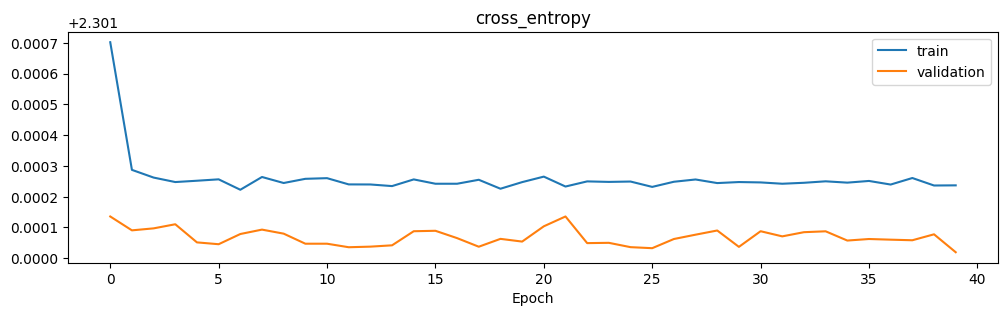

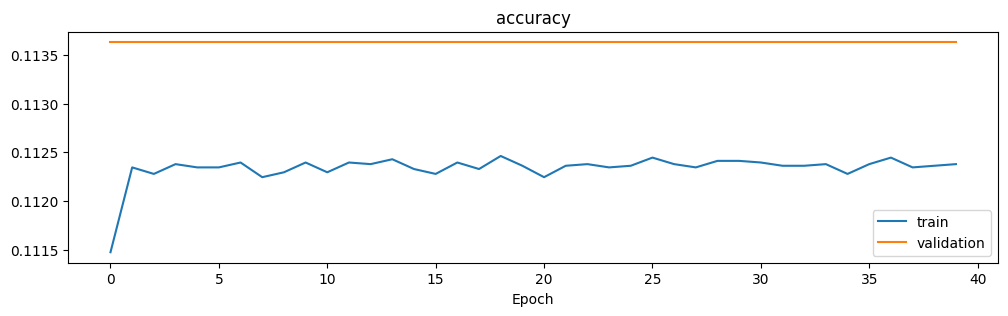

In [9]:
plot_learning_curves(metrics, keys=["cross_entropy", "accuracy"])

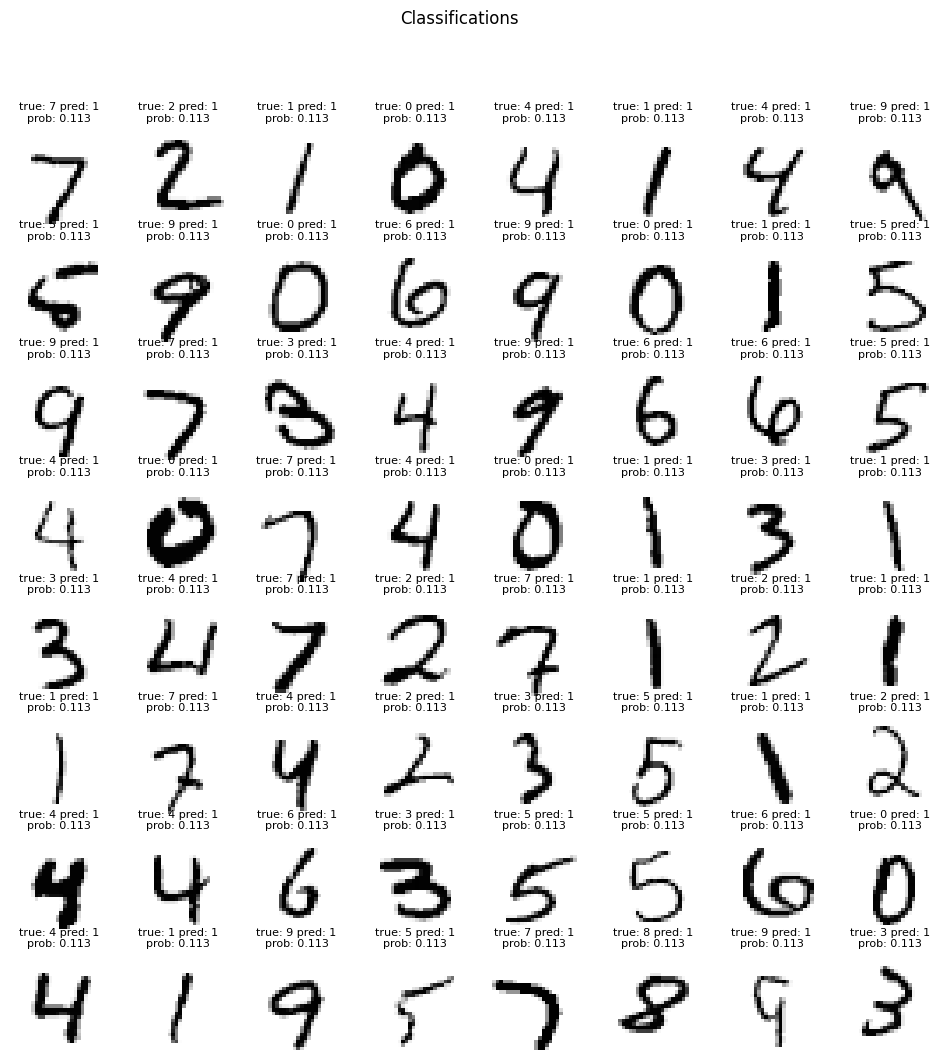

In [10]:
trainer.plot_examples()

## Tensorboard within notebook

In [11]:
%load_ext tensorboard

In [12]:
# NOTE!! In case you are running this on a local machine, this port must be unused.
# you also cannot run multiple TB instances on one port!
# but in general, having just one instance running on the log directory should be sufficient.
%tensorboard --logdir=logs --port=6006

Reusing TensorBoard on port 6006 (pid 14980), started 1:45:27 ago. (Use '!kill 14980' to kill it.)